In [55]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch, savgol_filter
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, MaxPooling1D
from tensorflow.keras.optimizers import Adam

print("All libraries loaded.")

fs = 9
folder_path = "Raw_temp/155" 
window_sec = 30
step_sec = 3

All libraries loaded.


In [56]:
from scipy.signal import find_peaks
def bandpass(signal, fs, low=0.8, high=2.5, order=3):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, signal)

def hampel_filter(signal, window_size=3):
    return signal - (signal - pd.Series(signal).rolling(window_size, center=True).median()).fillna(0)

In [132]:
files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))
print("Total files found:", len(files))

features = []
targets = []

for file in files:
    print("\nProcessing:", os.path.basename(file))
    df = pd.read_csv(file)

    amps = []
    for i in range(256):
        real = df[f"real_{i}"].values
        imag = df[f"imag_{i}"].values
        amp = np.sqrt(real**2 + imag**2)
        amps.append(amp)

    amp_matrix = np.array(amps).T

    for i in range(256):
        amp_matrix[:, i] = hampel_filter(amp_matrix[:, i])

    for i in range(256):
        amp_matrix[:, i] = savgol_filter(amp_matrix[:, i], 7, 2)

    filtered = np.zeros_like(amp_matrix)
    for i in range(256):
        filtered[:, i] = bandpass(amp_matrix[:, i], fs)

    signal = np.mean(filtered, axis=1)

    window_size = window_sec * fs
    step_size = step_sec * fs

    for start in range(0, len(signal)-window_size, step_size):
        segment = signal[start:start+window_size]

        f, pxx = welch(segment, fs=fs, nperseg=len(segment))

        mask = (f >= 0.8) & (f <= 2.5)
        f_band = f[mask]
        pxx_band = pxx[mask]

        if len(pxx_band) == 0:
            continue

        pxx_band = savgol_filter(pxx_band, 5, 2)
        pxx_band = pxx_band / (np.sum(pxx_band) + 1e-8)

        peak_freq = f_band[np.argmax(pxx_band)]
        weighted_freq = np.sum(f_band * pxx_band) / (np.sum(pxx_band) + 1e-8)
        peak_power = np.max(pxx_band)
        band_energy = np.sum(pxx_band)

        features.append([peak_freq, weighted_freq, peak_power, band_energy])

        targets.append(np.mean(
            df["heart_rate"].values[start:start+window_size]
        ))

features = np.array(features)
targets = np.array(targets)

diff_feature = np.diff(features[:,0], prepend=features[0,0])
features = np.hstack([features, diff_feature.reshape(-1,1)])

from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
features = scaler_X.fit_transform(features)



def create_sequences(X, y, seq_len=20):
    X_seq, y_seq, baseline = [], [], []
    
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])
        
        baseline.append(X[i+seq_len-1, 0])  # peak_freq (scaled)
    
    return np.array(X_seq), np.array(y_seq), np.array(baseline)

seq_len = 20
X_seq, y_seq, baseline = create_sequences(features, targets, seq_len)

print("Shape:", X_seq.shape, y_seq.shape)

Total files found: 17

Processing: 10_2023_09_26_-_14_09_09_bw_80_ch_36_csi.csv

Processing: 11_2023_09_26_-_14_11_15_bw_80_ch_36_csi.csv

Processing: 12_2023_09_26_-_14_13_12_bw_80_ch_36_csi.csv

Processing: 13_2023_09_26_-_14_15_56_bw_80_ch_36_csi.csv

Processing: 14_2023_09_26_-_14_17_51_bw_80_ch_36_csi.csv

Processing: 15_2023_09_26_-_14_20_03_bw_80_ch_36_csi.csv

Processing: 16_2023_09_26_-_14_21_35_bw_80_ch_36_csi.csv

Processing: 17_2023_09_26_-_14_23_03_bw_80_ch_36_csi.csv

Processing: 1_2023_09_26_-_13_46_43_bw_80_ch_36_csi.csv

Processing: 2_2023_09_26_-_13_50_25_bw_80_ch_36_csi.csv

Processing: 3_2023_09_26_-_13_53_00_bw_80_ch_36_csi.csv

Processing: 4_2023_09_26_-_13_56_09_bw_80_ch_36_csi.csv

Processing: 5_2023_09_26_-_13_57_47_bw_80_ch_36_csi.csv

Processing: 6_2023_09_26_-_13_59_34_bw_80_ch_36_csi.csv

Processing: 7_2023_09_26_-_14_03_23_bw_80_ch_36_csi.csv

Processing: 8_2023_09_26_-_14_05_02_bw_80_ch_36_csi.csv

Processing: 9_2023_09_26_-_14_07_02_bw_80_ch_36_csi.csv
S

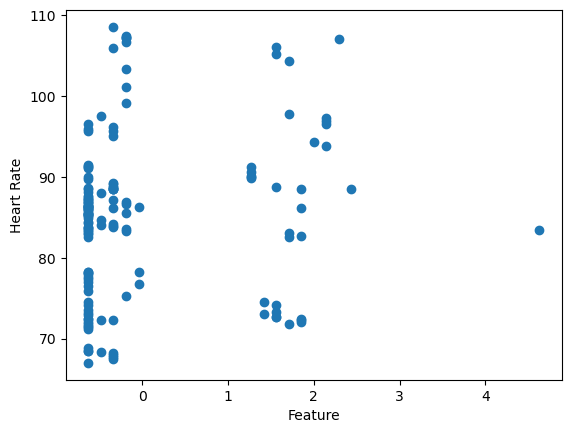

In [111]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], y)
plt.xlabel("Feature")
plt.ylabel("Heart Rate")
plt.show()

In [187]:
# 🔥 Strong baseline (smooth signal)
import pandas as pd

targets_series = pd.Series(targets)

baseline_hr = targets_series.rolling(window=5, min_periods=1).mean().values

# align with seq_len
baseline_hr = baseline_hr[seq_len:]
y_residual = targets[seq_len:] - baseline_hr

from sklearn.preprocessing import StandardScaler
res_scaler = StandardScaler()
y_residual = res_scaler.fit_transform(y_residual.reshape(-1,1)).flatten()

In [188]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, base_train, base_test = train_test_split(
    X_seq, y_residual, baseline_hr,
    test_size=0.2,
    shuffle=False
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (106, 20, 5) (106,)
Test: (27, 20, 5) (27,)


In [189]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1,activation='tanh')
])

model.compile(
    optimizer=Adam(0.0005),
    loss='huber',
    metrics=['mae']
)

model.summary()

C:\Users\Sneha\anaconda\envs\Minor\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_33 (LSTM)                       │ (None, 20, 64)              │          17,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_41 (Dropout)                 │ (None, 20, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_34 (LSTM)                       │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_42 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_44 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,937 (124.75 KB)

 Trainable params: 31,937 (124.75 KB)

 Non-trainable params: 0 (0.00 B)

In [190]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    min_delta=1e-4,
    verbose=1
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=4,
    min_lr=1e-6,
    cooldown=2,
    verbose=1
)

In [191]:
history = model.fit(
    X_train, y_train,
    epochs=5000, 
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, lr_reducer],
    verbose=1
)

Epoch 1/5000
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 398ms/step - loss: 0.3645 - mae: 0.6630 - val_loss: 0.0835 - val_mae: 0.3252 - learning_rate: 5.0000e-04
Epoch 2/5000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.3640 - mae: 0.6610 - val_loss: 0.0829 - val_mae: 0.3216 - learning_rate: 5.0000e-04
Epoch 3/5000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.3660 - mae: 0.6598 - val_loss: 0.0831 - val_mae: 0.3223 - learning_rate: 5.0000e-04
Epoch 4/5000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.3646 - mae: 0.6581 - val_loss: 0.0826 - val_mae: 0.3191 - learning_rate: 5.0000e-04
Epoch 5/5000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.3663 - mae: 0.6600 - val_loss: 0.0806 - val_mae: 0.3084 - learning_rate: 5.0000e-04
Epoch 6/5000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.3650 - mae: 0.6573 - val_loss: 0.0809 - val_mae: 0.3107 - learning_rate: 5.0000e-04
Epoch 7/5000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.3636 - mae: 0.6569 - val_loss: 0.0818 - val_mae: 0.3168 - learning_r

In [203]:

train_res_pred = model.predict(X_train).flatten()
test_res_pred  = model.predict(X_test).flatten()


train_res_pred = res_scaler.inverse_transform(train_res_pred.reshape(-1,1)).flatten()
test_res_pred  = res_scaler.inverse_transform(test_res_pred.reshape(-1,1)).flatten()


train_res_pred = train_res_pred - np.mean(train_res_pred)
test_res_pred  = test_res_pred  - np.mean(test_res_pred)


train_pred = base_train + train_res_pred
test_pred  = base_test  + test_res_pred


y_train_residual = res_scaler.inverse_transform(y_train.reshape(-1,1)).flatten()
y_train_true = base_train + y_train_residual

y_test_residual = res_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

y_test_true = base_test + y_test_residual


from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(y_train_true, train_pred)
test_mae = mean_absolute_error(y_test_true, test_pred)

train_mape = np.mean(
    np.abs((y_train_true - train_pred) / np.clip(y_train_true, 1, None))
) * 100

test_mape = np.mean(
    np.abs((y_test_true - test_pred) / np.clip(y_test_true, 1, None))
) * 100
gap = test_mae - train_mae
accuracy = 100 - test_mape

print("\n===== RESULTS =====")
print("Train MAE:", round(train_mae,2))
print("Test MAE:", round(test_mae,2))
print("Train MAPE:", round(train_mape,2), "%")
print("Test MAPE:", round(test_mape,2), "%")
print("Generalization GAP:", round(gap,2))
print("Pseudo Accuracy:", round(accuracy,2), "%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

===== RESULTS =====
Train MAE: 2.17
Test MAE: 0.94
Train MAPE: 2.44 %
Test MAPE: 1.06 %
Generalization GAP: -1.23
Pseudo Accuracy: 98.94 %


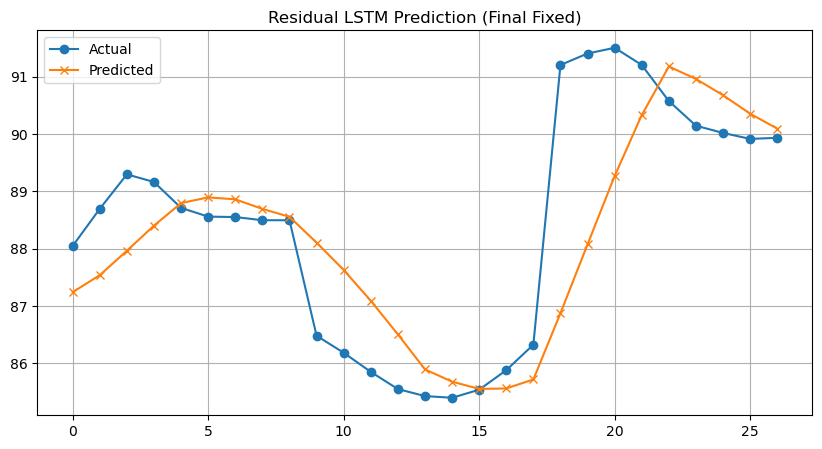

In [199]:
plt.figure(figsize=(10,5))

plt.plot(y_test_true, label="Actual", marker='o')
plt.plot(test_pred, label="Predicted", marker='x')

plt.legend()
plt.title("Residual LSTM Prediction (Final Fixed)")
plt.grid()
plt.show()

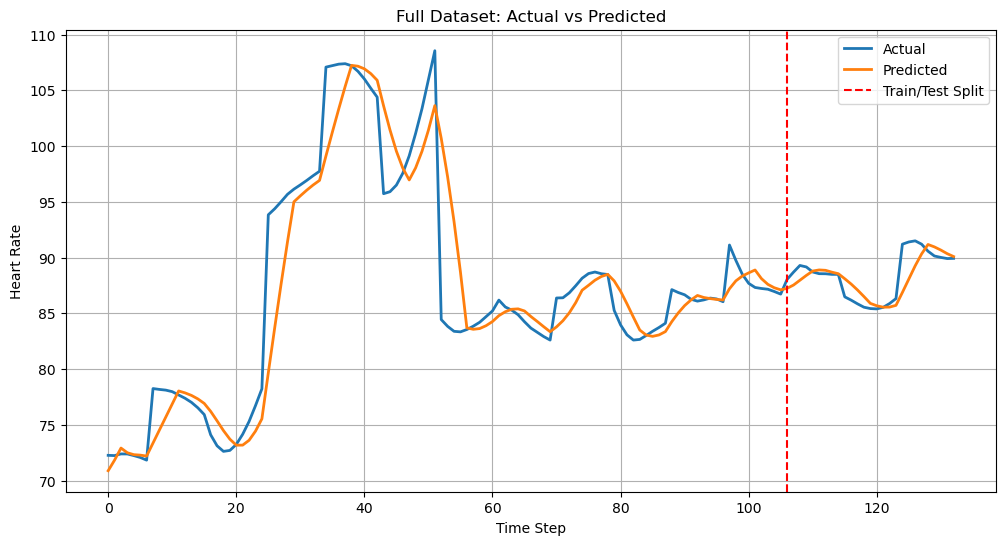

In [200]:
plt.figure(figsize=(12,6))

# Combine everything
all_actual = np.concatenate([y_train_true, y_test_true])
all_pred   = np.concatenate([train_pred, test_pred])

# Plot
plt.plot(all_actual, label="Actual", linewidth=2)
plt.plot(all_pred, label="Predicted", linewidth=2)

# Mark train/test split
split_point = len(y_train_true)
plt.axvline(x=split_point, color='red', linestyle='--', label='Train/Test Split')

plt.legend()
plt.title("Full Dataset: Actual vs Predicted")
plt.xlabel("Time Step")
plt.ylabel("Heart Rate")
plt.grid()
plt.show()



#MULTIPLE PARTICIPANTS (PARTICIPANT_WISE SPLIT)


In [19]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch, savgol_filter
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, MaxPooling1D
from tensorflow.keras.optimizers import Adam

print("All libraries loaded.")

fs = 9
root_folder = "Raw_temp"
window_sec = 20
step_sec = 5

All libraries loaded.


In [20]:

def bandpass(signal, fs, low=0.8, high=2.5, order=3):
    from scipy.signal import butter, filtfilt
    import numpy as np

    signal = np.array(signal)

    signal = np.nan_to_num(signal)
    if len(signal) <= 25:
        return np.zeros_like(signal)
    if np.std(signal) == 0:
        return np.zeros_like(signal)

    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')

    try:
        return filtfilt(b, a, signal)
    except:
        return np.zeros_like(signal)

def hampel_filter(signal, window_size=3):
    return signal - (signal - pd.Series(signal).rolling(window_size, center=True).median()).fillna(0)


def moving_average(signal, window_size=5):
    return pd.Series(signal).rolling(window_size, center=True).mean().fillna(method='bfill').fillna(method='ffill').values


In [21]:
# CELL 3

participants = sorted(os.listdir(root_folder))
print("Participants found:", participants)

X = []
y = []

for pid in participants:
    participant_path = os.path.join(root_folder, pid)
    
    if not os.path.isdir(participant_path):
        continue
        
    files = sorted(glob.glob(os.path.join(participant_path, "*.csv")))
    print(f"\nParticipant {pid} - Files found:", len(files))

    for file in files:
        print("\nProcessing:", os.path.basename(file))
        df = pd.read_csv(file)
        amps = []
        for i in range(256):
            real = df[f"real_{i}"].values
            imag = df[f"imag_{i}"].values
            amp = np.sqrt(real**2 + imag**2)
            amps.append(amp)
        amp_matrix = np.array(amps).T

        print("Amplitude matrix shape:", amp_matrix.shape)

        for i in range(256):
            amp_matrix[:, i] = hampel_filter(amp_matrix[:, i])

        for i in range(256):
            amp_matrix[:, i] = moving_average(amp_matrix[:, i], window_size=5)

        for i in range(256):
            amp_matrix[:, i] = savgol_filter(amp_matrix[:, i], 7, 2)

        filtered = np.zeros_like(amp_matrix)
        for i in range(amp_matrix.shape[1]):
            signal = amp_matrix[:, i]
            if len(signal) <= 25:
               continue
            filtered[:, i] = bandpass(amp_matrix[:, i], fs)

        pca = PCA(n_components=1)
        pca_signal = pca.fit_transform(filtered).flatten()

        print("PCA output shape:", pca_signal.shape)

        if np.std(pca_signal) == 0:
            print("WARNING: PCA signal is flat!")


        window_size = window_sec * fs
        step_size = step_sec * fs

        for start in range(0, len(pca_signal)-window_size, step_size):
            segment = pca_signal[start:start+window_size]

            f, pxx = welch(segment, fs=fs, nperseg=len(segment))

            mask = (f >= 0.8) & (f <= 2.5)
            f_band = f[mask]
            pxx_band = pxx[mask]

            if len(pxx_band) == 0:
                continue

            X.append(pxx_band)
            y.append(np.mean(df["heart_rate"].values[start:start+window_size]))

X = np.array(X)
y = np.array(y)

print("Final dataset shape:", X.shape, y.shape)

Participants found: ['074', '075', '076', '077', '078', '079', '080', '081', '082', '083', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '094', '095', '096', '097', '098', '099', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '155']

Participant 074 - Files found: 17

Processing: 10_2022_08_30_-_14_34_12_bw_80_ch_36_csi.csv
Amplitude matrix shape: (500, 256)


C:\Users\Sneha\AppData\Local\Temp\ipykernel_4840\1016622647.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.Series(signal).rolling(window_size, center=True).mean().fillna(method='bfill').fillna(method='ffill').values


PCA output shape: (500,)

Processing: 11_2022_08_30_-_14_36_41_bw_80_ch_36_csi.csv
Amplitude matrix shape: (500, 256)


C:\Users\Sneha\AppData\Local\Temp\ipykernel_4840\1016622647.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.Series(signal).rolling(window_size, center=True).mean().fillna(method='bfill').fillna(method='ffill').values


PCA output shape: (500,)

Processing: 12_2022_08_30_-_14_38_34_bw_80_ch_36_csi.csv
Amplitude matrix shape: (500, 256)


...

PCA output shape: (497,)

Processing: 8_2023_09_26_-_14_05_02_bw_80_ch_36_csi.csv
Amplitude matrix shape: (496, 256)


C:\Users\Sneha\AppData\Local\Temp\ipykernel_4840\1016622647.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.Series(signal).rolling(window_size, center=True).mean().fillna(method='bfill').fillna(method='ffill').values


PCA output shape: (496,)

Processing: 9_2023_09_26_-_14_07_02_bw_80_ch_36_csi.csv
Amplitude matrix shape: (500, 256)


C:\Users\Sneha\AppData\Local\Temp\ipykernel_4840\1016622647.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.Series(signal).rolling(window_size, center=True).mean().fillna(method='bfill').fillna(method='ffill').values


PCA output shape: (500,)
Final dataset shape: (6929, 35) (6929,)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [100]:
# CELL 4

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape for CNN + LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5543, 35, 1)
Test shape: (1386, 35, 1)


In [101]:

X_train = (X_train - np.mean(X_train, axis=1, keepdims=True)) / (np.std(X_train, axis=1, keepdims=True) + 1e-6)
X_test  = (X_test - np.mean(X_test, axis=1, keepdims=True)) / (np.std(X_test, axis=1, keepdims=True) + 1e-6)
y_mean = np.mean(y_train)
y_std = np.std(y_train)

y_train_norm = (y_train - y_mean) / y_std
y_test_norm = (y_test - y_mean) / y_std

In [102]:
# CELL 5 (UPDATED WITH CALLBACKS)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,
    min_lr=1e-6,
    verbose=0
)
print("Callbacks ready.")

Callbacks ready.


In [103]:
# CELL 5 (UPDATED)

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Dropout, BatchNormalization, Add
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 🔥 Hybrid Loss (IMPORTANT)
def hybrid_loss(y_true, y_pred):
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    mape = tf.reduce_mean(tf.abs((y_true - y_pred) / (y_true + 1e-6)))
    return mae + mape

# 🔥 Model with residual connection
inputs = Input(shape=(X_train.shape[1],1))

x = Conv1D(64, 5, activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)

# Residual block
res = Conv1D(64, 3, activation='relu', padding='same')(x)
res = BatchNormalization()(res)

x = Add()([x, res])

x = LSTM(64, return_sequences=True)(x)
x = Dropout(0.2)(x)

x = LSTM(64)(x)
x = Dropout(0.2)(x)

x = Dense(64, activation='relu')(x)
x = Dense(16, activation='relu')(x)

outputs = Dense(1)(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.0003, clipnorm=1.0),
    loss=hybrid_loss,
    metrics=['mae']
)

model.summary()

Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)   │ (None, 35, 1)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_41 (Conv1D)            │ (None, 35, 64)            │             384 │ input_layer_25[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_39        │ (None, 35, 64)            │             256 │ conv1d_41[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_42 (Conv1D)            │ (None, 35, 64)            │          12,352 │ batch_normalization_39[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_40        │ (None, 35, 64)            │             256 │ conv1d_42[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_6 (Add)                   │ (None, 35, 64)            │               0 │ batch_normalization_39[0]… │
│                               │                           │                 │ batch_normalization_40[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_48 (LSTM)                │ (None, 35, 64)            │          33,024 │ add_6[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_76 (Dropout)          │ (None, 35, 64)            │               0 │ lstm_48[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_49 (LSTM)                │ (None, 64)                │          33,024 │ dropout_76[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_77 (Dropout)          │ (None, 64)                │               0 │ lstm_49[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_52 (Dense)              │ (None, 64)                │           4,160 │ dropout_77[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_53 (Dense)              │ (None, 16)                │           1,040 │ dense_52[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_54 (Dense)              │ (None, 1)                 │              17 │ dense_53[0][0]             │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 84,513 (330.13 KB)

 Trainable params: 84,257 (329.13 KB)

 Non-trainable params: 256 (1.00 KB)

In [104]:
# CELL 6 (UPDATED TRAINING)

history = model.fit(
    X_train, y_train_norm,
    epochs=5000,  # Increased because early stopping will stop automatically
    batch_size=32,
    validation_data=(X_test, y_test_norm),
    callbacks=[early_stop, lr_reducer],
    shuffle=True,
    verbose=1
)

Epoch 1/5000
174/174 ━━━━━━━━━━━━━━━━━━━━ 26s 79ms/step - loss: 2.3166 - mae: 0.7978 - val_loss: 1.9919 - val_mae: 0.8238 - learning_rate: 3.0000e-04
Epoch 2/5000
174/174 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - loss: 2.0602 - mae: 0.7953 - val_loss: 1.9163 - val_mae: 0.8217 - learning_rate: 3.0000e-04
Epoch 3/5000
174/174 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - loss: 2.0085 - mae: 0.7973 - val_loss: 1.8515 - val_mae: 0.8192 - learning_rate: 3.0000e-04
Epoch 4/5000
174/174 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - loss: 1.9189 - mae: 0.7966 - val_loss: 1.8327 - val_mae: 0.8206 - learning_rate: 3.0000e-04
Epoch 5/5000
174/174 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - loss: 1.8344 - mae: 0.7970 - val_loss: 1.8287 - val_mae: 0.8195 - learning_rate: 3.0000e-04
Epoch 6/5000
174/174 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - loss: 1.8218 - mae: 0.7969 - val_loss: 1.8347 - val_mae: 0.8195 - learning_rate: 3.0000e-04
Epoch 7/5000
174/174 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - loss: 1.8718 - mae: 0.7964 - val_loss: 1.8

In [105]:
# CELL 7 (UPDATED)

from sklearn.metrics import mean_absolute_error
import numpy as np

# 🔹 Predictions
train_pred = model.predict(X_train).flatten()

test_pred  = model.predict(X_test).flatten()

# 🔹 De-normalize
train_pred = train_pred * y_std + y_mean
test_pred  = test_pred * y_std + y_mean

from scipy.signal import medfilt

train_pred = medfilt(train_pred, kernel_size=15)
test_pred  = medfilt(test_pred, kernel_size=15)
bias = np.mean(y_train - train_pred)

train_pred = train_pred + bias
test_pred  = test_pred + bias
# 🔥 1. Smooth predictions (reduces noise)


# 🔥 2. Clip unrealistic HR values
pred_plot = np.clip(test_pred, 50, 150)

# 🔥 3. Safe MAPE (avoid divide by zero)
epsilon = 1e-6

train_mae = mean_absolute_error(y_train, train_pred)
test_mae  = mean_absolute_error(y_test, test_pred)

train_mape = np.mean(np.abs((y_train - train_pred) / (y_train + epsilon))) * 100
test_mape  = np.mean(np.abs((y_test - test_pred) / (y_test + epsilon))) * 100

# 🔥 4. Generalization gap
gap = test_mae - train_mae

# 🔥 5. Better accuracy metric
accuracy = 100 - test_mape

# 🔹 Print results
print("\n===== RESULTS (Improved) =====")
print("Train MAE:", round(train_mae, 2))
print("Test MAE:", round(test_mae, 2))
print("Train MAPE:", round(train_mape, 2), "%")
print("Test MAPE:", round(test_mape, 2), "%")
print("Generalization GAP:", round(gap, 2))
print("Pseudo Accuracy:", round(accuracy, 2), "%")

174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

===== RESULTS (Improved) =====
Train MAE: 13.16
Test MAE: 13.52
Train MAPE: 15.83 %
Test MAPE: 16.23 %
Generalization GAP: 0.37
Pseudo Accuracy: 83.77 %


In [65]:

def build_model(conv_filters, lstm_units, dense_units, dropout, lr):
    model = Sequential([

        Conv1D(conv_filters, 5, activation='relu', input_shape=(X_train.shape[1],1)),
        BatchNormalization(),
        Dropout(dropout),

        Conv1D(conv_filters, 3, activation='relu'),
        BatchNormalization(),
        Dropout(dropout),

        LSTM(lstm_units, return_sequences=True),
        Dropout(dropout),

        LSTM(lstm_units),
        Dropout(dropout),

        Dense(dense_units, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr, clipnorm=1.0),
        loss='mae',
        metrics=['mae']
    )
    return model

In [66]:
def compute_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100

In [68]:
import random
results = []

for i in range(7):   # try 5–10 configs
    print(f"\n🔹 Trial {i+1}")

    conv_filters = random.choice([2,4,8,16,32, 64, 128])
    lstm_units   = random.choice([2,4,8,16,32, 64, 128])
    dense_units  = random.choice([2,4,8,16, 32, 64])
    dropout      = random.choice([0.1, 0.2, 0.3,0.5,0.4])
    lr           = random.choice([1e-4, 3e-4, 5e-4])

    model = build_model(conv_filters, lstm_units, dense_units, dropout, lr)

    model.fit(
        X_train, y_train_norm,
        validation_data=(X_test, y_test_norm),
        epochs=30,
        batch_size=64,
        verbose=0
    )

    # 🔥 Predict
    pred = model.predict(X_test).flatten()
    pred = pred * y_std + y_mean

    # 🔥 Metrics
    mae  = np.mean(np.abs(pred - y_test))
    mape = compute_mape(y_test, pred)

    print(f"Params → filters:{conv_filters}, lstm:{lstm_units}, dense:{dense_units}, drop:{dropout}, lr:{lr}")
    print(f"MAE: {mae:.2f} | MAPE: {mape:.2f}%")

    results.append((mape, mae, conv_filters, lstm_units, dense_units, dropout, lr))


🔹 Trial 1


C:\Users\Sneha\anaconda\envs\Minor\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
Params → filters:64, lstm:8, dense:16, drop:0.4, lr:0.0003
MAE: 13.11 | MAPE: 15.52%

🔹 Trial 2
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
Params → filters:2, lstm:32, dense:2, drop:0.1, lr:0.0005
MAE: 13.24 | MAPE: 15.58%

🔹 Trial 3
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
Params → filters:2, lstm:16, dense:8, drop:0.1, lr:0.0003
MAE: 13.23 | MAPE: 15.54%

🔹 Trial 4
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
Params → filters:32, lstm:32, dense:16, drop:0.2, lr:0.0003
MAE: 12.97 | MAPE: 15.42%

🔹 Trial 5
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step
Params → filters:64, lstm:64, dense:32, drop:0.4, lr:0.0005
MAE: 13.00 | MAPE: 15.27%

🔹 Trial 6
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
Params → filters:32, lstm:4, dense:64, drop:0.4, lr:0.0001
MAE: 13.24 | MAPE: 15.64%

🔹 Trial 7
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
Params → filters:2, lstm:8, dense:16, drop:0.1, lr:0.0003
MAE: 13.22 | MAPE: 15.52%


In [69]:
best = sorted(results, key=lambda x: x[0])[0]

print("\n🔥 BEST CONFIG (by MAPE):")
print("MAPE:", best[0])
print("MAE:", best[1])
print("Filters:", best[2])
print("LSTM:", best[3])
print("Dense:", best[4])
print("Dropout:", best[5])
print("LR:", best[6])


🔥 BEST CONFIG (by MAPE):
MAPE: 15.273236231512346
MAE: 12.995712754551988
Filters: 64
LSTM: 64
Dense: 32
Dropout: 0.4
LR: 0.0005


In [206]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch, savgol_filter
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, MaxPooling1D
from tensorflow.keras.optimizers import Adam

print("All libraries loaded.")

fs = 9
base_path = "Raw_temp"
window_sec = 30
step_sec = 3

participants = sorted(os.listdir(base_path))

print(len(participants))
print(participants)

All libraries loaded.
55
['074', '075', '076', '077', '078', '079', '080', '081', '082', '083', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '094', '095', '096', '097', '098', '099', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '155']


In [209]:
from scipy.signal import find_peaks

def bandpass(signal, fs, low=0.8, high=2.5, order=3):
    if len(signal) < 25:   # 🔥 critical fix (padlen ~ 21)
        return signal      # skip filtering safely

    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, signal)
    
def hampel_filter(signal, window_size=3):
    return signal - (signal - pd.Series(signal).rolling(window_size, center=True).median()).fillna(0)

all_X = []
all_y = []
all_base = []
all_pid = []

print("🚀 Starting processing...\n")

for pid_idx, pid in enumerate(participants):
    print(f"\n==============================")
    print(f"👤 Processing Participant {pid_idx+1}/{len(participants)}: {pid}")

    folder_path = os.path.join(base_path, pid)
    files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))

    

    features = []
    targets = []

    for file_idx, file in enumerate(files):
        print(f"\n   📄 File {file_idx+1}/{len(files)}: {os.path.basename(file)}")

        df = pd.read_csv(file)
        

        amps = []
        for i in range(256):
            real = df[f"real_{i}"].values
            imag = df[f"imag_{i}"].values
            amp = np.sqrt(real**2 + imag**2)
            amps.append(amp)

        amp_matrix = np.array(amps).T
        

        for i in range(256):
            amp_matrix[:, i] = hampel_filter(amp_matrix[:, i])
        

        for i in range(256):
            amp_matrix[:, i] = savgol_filter(amp_matrix[:, i], 7, 2)
        
        filtered = np.zeros_like(amp_matrix)
        for i in range(256):
            filtered[:, i] = bandpass(amp_matrix[:, i], fs)
        

        signal = np.mean(filtered, axis=1)
        

        window_size = window_sec * fs
        step_size = step_sec * fs

        window_count = 0

        for start in range(0, len(signal)-window_size, step_size):
            segment = signal[start:start+window_size]

            f, pxx = welch(segment, fs=fs, nperseg=len(segment))

            mask = (f >= 0.8) & (f <= 2.5)
            f_band = f[mask]
            pxx_band = pxx[mask]

            if len(pxx_band) == 0:
                continue

            pxx_band = savgol_filter(pxx_band, 5, 2)
            pxx_band = pxx_band / (np.sum(pxx_band) + 1e-8)

            peak_freq = f_band[np.argmax(pxx_band)]
            weighted_freq = np.sum(f_band * pxx_band) / (np.sum(pxx_band) + 1e-8)
            peak_power = np.max(pxx_band)
            band_energy = np.sum(pxx_band)

            features.append([peak_freq, weighted_freq, peak_power, band_energy])
            targets.append(np.mean(df["heart_rate"].values[start:start+window_size]))

            window_count += 1

        print(f"   🪟 Windows processed: {window_count}")

    features = np.array(features)
    targets = np.array(targets)

    print("\n📊 Feature matrix shape:", features.shape)
    print("📊 Target shape:", targets.shape)

    diff_feature = np.diff(features[:,0], prepend=features[0,0])
    features = np.hstack([features, diff_feature.reshape(-1,1)])
    print("➕ Added diff feature. New shape:", features.shape)

    from sklearn.preprocessing import MinMaxScaler
    scaler_X = MinMaxScaler()
    features = scaler_X.fit_transform(features)
    print("🔄 Features normalized")

    def create_sequences(X, y, seq_len=20):
        X_seq, y_seq, baseline = [], [], []
        for i in range(len(X) - seq_len):
            X_seq.append(X[i:i+seq_len])
            y_seq.append(y[i+seq_len])
            baseline.append(X[i+seq_len-1, 0])
        return np.array(X_seq), np.array(y_seq), np.array(baseline)

    seq_len = 20
    X_seq, y_seq, baseline = create_sequences(features, targets, seq_len)

    print("📦 Sequences created:")
    print("   X_seq:", X_seq.shape)
    print("   y_seq:", y_seq.shape)

    all_X.append(X_seq)
    all_y.append(y_seq)
    all_base.append(baseline)
    all_pid.extend([pid]*len(X_seq))

# Final aggregation
X_all = np.concatenate(all_X)
y_all = np.concatenate(all_y)
base_all = np.concatenate(all_base)
pid_all = np.array(all_pid)

print("\n==============================")
print("🎯 FINAL DATASET")
print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
print("baseline shape:", base_all.shape)
print("participants shape:", pid_all.shape)
print("==============================")

🚀 Starting processing...


👤 Processing Participant 1/55: 074

   📄 File 1/17: 10_2022_08_30_-_14_34_12_bw_80_ch_36_csi.csv
   🪟 Windows processed: 9

   📄 File 2/17: 11_2022_08_30_-_14_36_41_bw_80_ch_36_csi.csv
   🪟 Windows processed: 9

   📄 File 3/17: 12_2022_08_30_-_14_38_34_bw_80_ch_36_csi.csv
   🪟 Windows processed: 9

   📄 File 4/17: 13_2022_08_30_-_14_40_22_bw_80_ch_36_csi.csv
   🪟 Windows processed: 9

   📄 File 5/17: 14_2022_08_30_-_14_42_23_bw_80_ch_36_csi.csv
   🪟 Windows processed: 8

   📄 File 6/17: 15_2022_08_30_-_14_44_00_bw_80_ch_36_csi.csv
   🪟 Windows processed: 9

   📄 File 7/17: 16_2022_08_30_-_14_45_36_bw_80_ch_36_csi.csv
   🪟 Windows processed: 8

   📄 File 8/17: 17_2022_08_30_-_14_47_16_bw_80_ch_36_csi.csv
   🪟 Windows processed: 9

   📄 File 9/17: 1_2022_08_30_-_14_20_59_bw_80_ch_36_csi.csv
   🪟 Windows processed: 9

   📄 File 10/17: 2_2022_08_30_-_14_22_34_bw_80_ch_36_csi.csv
   🪟 Windows processed: 9

   📄 File 11/17: 3_2022_08_30_-_14_24_02_bw_80_ch_36_csi.c

In [210]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

baseline_list = []
residual_list = []

start = 0
for X_part, y_part, base_part in zip(all_X, all_y, all_base):
    targets_series = pd.Series(y_part)
    baseline_hr = targets_series.rolling(window=5, min_periods=1).mean().values

    baseline_list.append(baseline_hr)

    y_residual = y_part - baseline_hr
    residual_list.append(y_residual)

baseline_hr = np.concatenate(baseline_list)
y_residual = np.concatenate(residual_list)

res_scaler = StandardScaler()

unique_pids = np.unique(pid_all)
split_idx = int(0.8 * len(unique_pids))

train_pids = unique_pids[:split_idx]
test_pids = unique_pids[split_idx:]

train_mask = np.isin(pid_all, train_pids)
test_mask  = np.isin(pid_all, test_pids)

X_train = X_all[train_mask]
X_test  = X_all[test_mask]

y_train = y_residual[train_mask]
y_test  = y_residual[test_mask]

base_train = baseline_hr[train_mask]
base_test  = baseline_hr[test_mask]

y_train = res_scaler.fit_transform(y_train.reshape(-1,1)).flatten()
y_test  = res_scaler.transform(y_test.reshape(-1,1)).flatten()

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(5610, 20, 5) (5610,)
(1450, 20, 5) (1450,)


In [211]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='tanh')
])

model.compile(
    optimizer=Adam(0.0005),
    loss='huber',
    metrics=['mae']
)

model.summary()

C:\Users\Sneha\anaconda\envs\Minor\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_35 (LSTM)                       │ (None, 20, 128)             │          68,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_43 (Dropout)                 │ (None, 20, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_36 (LSTM)                       │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_44 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 120,641 (471.25 KB)

 Trainable params: 120,641 (471.25 KB)

 Non-trainable params: 0 (0.00 B)

In [212]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    min_delta=1e-4,
    verbose=1
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=4,
    min_lr=1e-6,
    cooldown=2,
    verbose=1
)

In [213]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, lr_reducer],
    verbose=1
)

Epoch 1/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 24s 104ms/step - loss: 0.2846 - mae: 0.5430 - val_loss: 0.2596 - val_mae: 0.5405 - learning_rate: 5.0000e-04
Epoch 2/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 0.2842 - mae: 0.5450 - val_loss: 0.2585 - val_mae: 0.5321 - learning_rate: 5.0000e-04
Epoch 3/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 0.2838 - mae: 0.5431 - val_loss: 0.2593 - val_mae: 0.5361 - learning_rate: 5.0000e-04
Epoch 4/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.2830 - mae: 0.5429 - val_loss: 0.2584 - val_mae: 0.5336 - learning_rate: 5.0000e-04
Epoch 5/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.2830 - mae: 0.5428 - val_loss: 0.2599 - val_mae: 0.5342 - learning_rate: 5.0000e-04
Epoch 6/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.2824 - mae: 0.5407 - val_loss: 0.2591 - val_mae: 0.5364 - learning_rate: 5.0000e-04
Epoch 7/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.2826 - mae: 0.5419 - val_loss: 0.2583 - val_mae: 0.5298 - le

In [214]:

train_res_pred = model.predict(X_train).flatten()
test_res_pred  = model.predict(X_test).flatten()


train_res_pred = res_scaler.inverse_transform(train_res_pred.reshape(-1,1)).flatten()
test_res_pred  = res_scaler.inverse_transform(test_res_pred.reshape(-1,1)).flatten()


train_res_pred = train_res_pred - np.mean(train_res_pred)
test_res_pred  = test_res_pred  - np.mean(test_res_pred)


train_pred = base_train + train_res_pred
test_pred  = base_test  + test_res_pred


y_train_residual = res_scaler.inverse_transform(y_train.reshape(-1,1)).flatten()
y_train_true = base_train + y_train_residual

y_test_residual = res_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

y_test_true = base_test + y_test_residual


from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(y_train_true, train_pred)
test_mae = mean_absolute_error(y_test_true, test_pred)

train_mape = np.mean(
    np.abs((y_train_true - train_pred) / np.clip(y_train_true, 1, None))
) * 100

test_mape = np.mean(
    np.abs((y_test_true - test_pred) / np.clip(y_test_true, 1, None))
) * 100
gap = test_mae - train_mae
accuracy = 100 - test_mape

print("\n===== RESULTS =====")
print("Train MAE:", round(train_mae,2))
print("Test MAE:", round(test_mae,2))
print("Train MAPE:", round(train_mape,2), "%")
print("Test MAPE:", round(test_mape,2), "%")
print("Generalization GAP:", round(gap,2))
print("Pseudo Accuracy:", round(accuracy,2), "%")

176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

===== RESULTS =====
Train MAE: 2.19
Test MAE: 2.11
Train MAPE: 2.49 %
Test MAPE: 2.61 %
Generalization GAP: -0.08
Pseudo Accuracy: 97.39 %


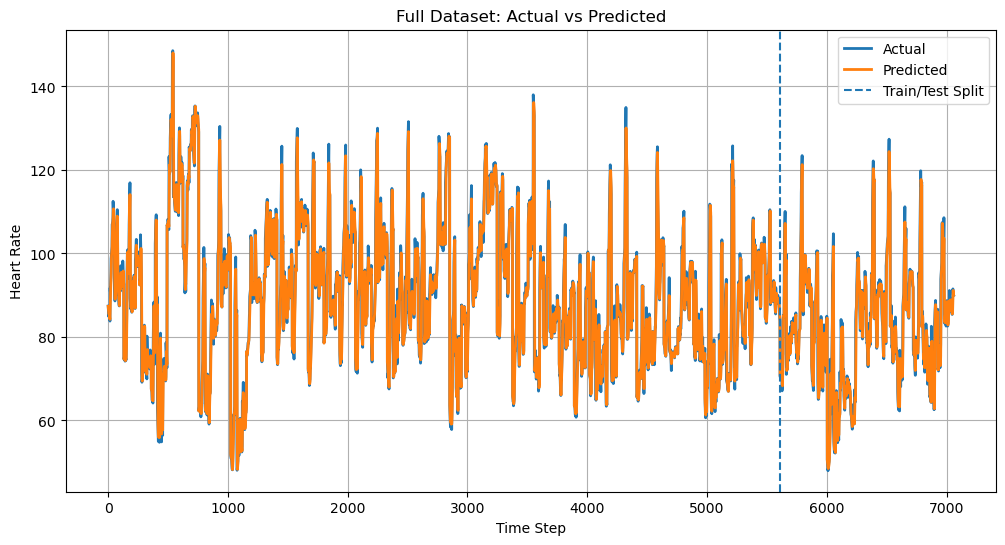

In [215]:
plt.figure(figsize=(12,6))

all_actual = np.concatenate([y_train_true, y_test_true])
all_pred   = np.concatenate([train_pred, test_pred])

plt.plot(all_actual, label="Actual", linewidth=2)
plt.plot(all_pred, label="Predicted", linewidth=2)

split_point = len(y_train_true)
plt.axvline(x=split_point, linestyle='--', label='Train/Test Split')

plt.legend()
plt.title("Full Dataset: Actual vs Predicted")
plt.xlabel("Time Step")
plt.ylabel("Heart Rate")
plt.grid()
plt.show()